In [1]:
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score
)
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from collections import Counter
from imblearn.over_sampling import SMOTE
import seaborn as sns


## Load the dataset

In [2]:
# Path
MODELS_DIR    = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

In [3]:
# Training data — use the SMOTE-balanced version
X_train = np.load("../Data/processed/X_train_smote.npy")
y_train = np.load("../Data/processed/y_train_smote.npy")

# Validation data — always from the original split (NO SMOTE)
X_val = np.load("../Data/processed/X_val.npy")
y_val = np.load("../Data/processed/y_val.npy")

# Test data — always from the original split (NO SMOTE)
X_test = np.load("../Data/processed/X_test.npy")
y_test = np.load("../Data/processed/y_test.npy")

In [4]:
# --- Hyperparameters ---
USE_SMOTE = True
BATCH_SIZE = 128
EPOCHS = 50
LEARNING_RATE = 1e-3
PATIENCE = 5
INPUT_SHAPE = (X_train.shape[1], 1)
NUM_CLASSES = len(np.unique(y_train))

## Normalize the heartbeat with z-score

Normalization is essential for ECG. It's probably the single biggest thing you can do to improve accuracy beyond model architecture changes.
Why ECG specifically needs it:

Patient-level baseline drift — Every patient has a different resting voltage. A "normal" beat from patient A might peak at 1.2 mV, while patient B's peaks at 0.4 mV. Without normalization, the model learns "patient A = amplitude high" instead of "QRS shape = normal."
Electrode placement differs — Amplitudes vary just based on how sensors are attached, which has nothing to do with arrhythmia class.
Batch normalization inside the network doesn't fully fix this — BN normalizes across the batch, but if entire patient recordings have systematically different scales, the model still picks up on it.

In [5]:
# Normalize with z-score per beat (subtract mean, divide by std)
def zscore(x):
    mean = x.mean(axis=1, keepdims=True) 
    std  = x.std(axis=1, keepdims=True) + 1e-8
    return (x - mean) / std

X_train = zscore(X_train).astype(np.float32)
X_val   = zscore(X_val).astype(np.float32)
X_test  = zscore(X_test).astype(np.float32)

print(f"Train shape: {X_train.shape}, {y_train.shape}")
print(f"Val shape: {X_val.shape}, {y_val.shape}")
print(f"Test shape: {X_test.shape}, {y_test.shape}")


Train shape: (252972, 250), (252972,)
Val shape: (15174, 250), (15174,)
Test shape: (15175, 250), (15175,)


In [6]:
# Reshape for PyTorch Conv1d: (batch, channels=1, length)
X_train = X_train[:, np.newaxis, :]
X_val   = X_val[:,   np.newaxis, :]
X_test  = X_test[:,  np.newaxis, :]

y_train = y_train.astype(np.int64)
y_val   = y_val.astype(np.int64)
y_test  = y_test.astype(np.int64)

print(f'Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}')
print(f'Train class distribution: {dict(Counter(y_train.tolist()))}')

Train: (252972, 1, 250) | Val: (15174, 1, 250) | Test: (15175, 1, 250)
Train class distribution: {0: 63243, 1: 63243, 2: 63243, 3: 63243}


## CNN model

In [7]:
# Device
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")

In [8]:
# Label names and num classes
LABEL_NAMES = ["N (Normal)", "S (Supravent.)", "V (Ventric.)", "F (Fusion)"]
NUM_CLASSES = 4

In [9]:
# data loader
def make_loader(X, y, batch_size, shuffle):
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=0)

train_loader = make_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   BATCH_SIZE, shuffle=False)
test_loader  = make_loader(X_test,  y_test,  BATCH_SIZE, shuffle=False)

print(f'Train batches: {len(train_loader)}')
print(f'Val batches  : {len(val_loader)}')
print(f'Test batches : {len(test_loader)}')

Train batches: 1977
Val batches  : 119
Test batches : 119


In [10]:
# Model definition
class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        
        self.features = nn.Sequential(
            # wide kernel for QRS complex
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.2),
            
            # narrower kernel to capture finer details
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.3),
            
            # Fine morphological features
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(0.4),
            
            # Global average pooling to reduce to (batch_size, 128, 1)
            nn.AdaptiveAvgPool1d(1),
        )
            
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )
        
    def forward(self, x):
        return self.classifier(self.features(x))

model = CNNModel(NUM_CLASSES).to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}\n')
print(model) 

        
        


Trainable parameters: 44,228

CNNModel(
  (features): Sequential(
    (0): Conv1d(1, 32, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.2, inplace=False)
    (5): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU(inplace=True)
    (8): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout(p=0.3, inplace=False)
    (10): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (11): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU(inplace=True)
    (13): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Dropout(p=0.4, inplace=False)
 

In [11]:
if USE_SMOTE:
    criterion = nn.CrossEntropyLoss()
else:
    classes = np.unique(y_train)
    weights = compute_class_weight('balanced', classes=classes, y=y_train)
    class_weights = torch.tensor(weights, dtype=torch.float32).to(DEVICE)
    print(f'Class weights: {dict(zip(classes.tolist(), weights.tolist()))}')
    criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=4, min_lr=1e-6
)

In [12]:
# Training loop and evaluation
def run_epoch(model, loader, criterion, optimizer=None):
    # Set model mode
    model.train() if optimizer else model.eval()
    total_loss = 0.0
    total_samples = 0
    total_correct = 0
    all_preds = []
    all_labels = []
    
    # Disable gradients during evaluation
    with torch.set_grad_enabled(optimizer is not None):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            outputs = model(xb)
            loss = criterion(outputs, yb)

            if optimizer:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
           
            preds = outputs.argmax(dim=1)
            total_loss += loss.item() * xb.size(0)
            total_samples += yb.size(0)
            total_correct += (preds == yb).sum().item()
            
            if not optimizer:  # Only collect predictions during evaluation
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(yb.cpu().numpy())

    # Compute metrics
    avg_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    f1 = f1_score(all_labels, all_preds, average='weighted')
    print(f"Epoch {epoch}: Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}, F1 Score: {f1:.4f}")

    return avg_loss, accuracy, f1, np.array(all_labels), np.array(all_preds)


In [13]:
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_val_loss = float('inf')
epochs_without_improvement = 0
ckpt_path = f'{MODELS_DIR}/cnn_baseline.pt'

print('Training...\n')
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, _, _ = run_epoch(model, train_loader, criterion, optimizer)
    va_loss, va_acc, _, _ = run_epoch(model, val_loader,   criterion)

    scheduler.step(va_loss)

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc)
    history['val_acc'].append(va_acc)

    improved = va_loss < best_val_loss
    if improved:
        best_val_loss = va_loss
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    marker = '  <-- best' if improved else ''
    print(f'Epoch {epoch:3d}/{EPOCHS} | '
          f'train loss={tr_loss:.4f} acc={tr_acc:.4f} | '
          f'val loss={va_loss:.4f} acc={va_acc:.4f}{marker}')

    if epochs_without_improvement >= PATIENCE:
        print(f'\nEarly stopping: no improvement for {PATIENCE} epochs')
        break

print(f'\nBest val loss: {best_val_loss:.4f}')

Training...



KeyboardInterrupt: 

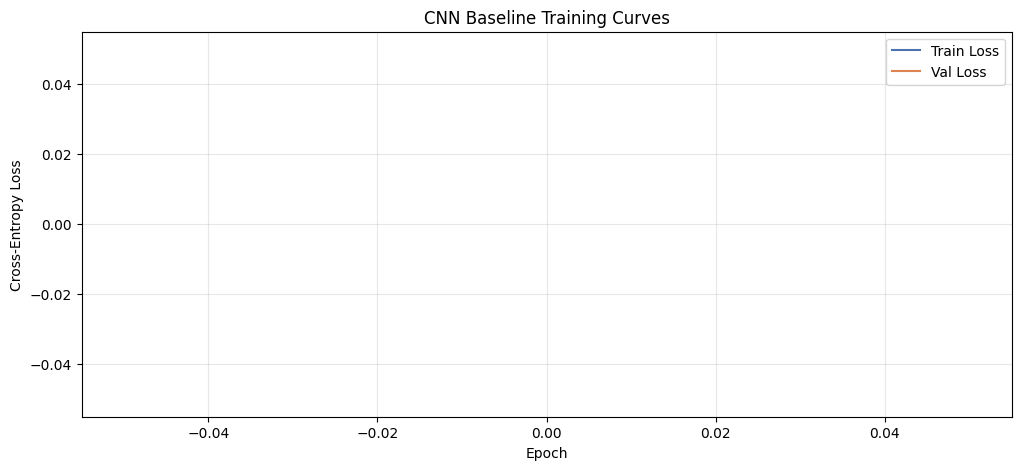

In [14]:
# Training curves
fig = plt.figure(figsize=(12, 5))
plt.plot(history['train_loss'], label='Train Loss', color='#4C72B0')
plt.plot(history['val_loss'], label='Val Loss', color='#DD8452')
set_title = 'CNN Baseline Training Curves'
plt.title(set_title)
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Training accuracy curves
fig = plt.figure(figsize=(12, 5))
plt.plot(history['train_acc'], label='Train Acc', color='#4C72B0')
plt.plot(history['val_acc'], label='Val Acc', color='#DD8452')
set_title = 'CNN Baseline Training Curves'
plt.title(set_title)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()